In [208]:
import seaborn as sns
df_titanic = sns.load_dataset('titanic')
display(df_titanic.head())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [209]:
import pandas as pd
import seaborn as sns
df_titanic = sns.load_dataset('titanic')

df_titanic['age'] = df_titanic['age'].fillna(df_titanic['age'].median())
df_titanic.drop(['deck', 'embark_town'], axis=1, inplace=True)
df_titanic['embarked'] = df_titanic['embarked'].fillna(df_titanic['embarked'].mode()[0])
df_titanic.drop(['who', 'adult_male', 'alone'], axis=1, inplace=True)

df_titanic['sex'] = df_titanic['sex'].map({'male': 0, 'female': 1})
df_titanic = pd.get_dummies(df_titanic, columns=['embarked'], drop_first=True)
df_titanic = pd.get_dummies(df_titanic, columns=['class'], drop_first=True)
df_titanic['alive'] = df_titanic['alive'].map({'no': 0, 'yes': 1})

X = df_titanic.drop('survived', axis=1)
y = df_titanic['survived']
display(X.head())

,pclass,sex,age,sibsp,parch,fare,alive,embarked_Q,embarked_S,class_Second,class_Third
0,3,0,22.0,1,0,7.2500,0,False,True,False,True
1,1,1,38.0,1,0,71.2833,1,False,False,False,False
2,3,1,26.0,0,0,7.9250,1,False,True,False,True
3,1,1,35.0,1,0,53.1000,1,False,True,False,False
4,3,0,35.0,0,0,8.0500,0,False,True,False,True


In [210]:
from sklearn.model_selection import train_test_split

# First split: 85% for train+validation, 15% for test
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Second split: From the train+validation set, take 15/85 (approx 17.6%) for validation
# This results in roughly 70% train, 15% validation, 15% test of the original data
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=(0.15/0.85), random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (623, 11)
X_val shape: (134, 11)
X_test shape: (134, 11)
y_train shape: (623,)
y_val shape: (134,)
y_test shape: (134,)


### 'age' 및 'fare' 컬럼 표준화

신경망의 학습 효율성과 성능을 향상시키기 위해 `age`와 `fare`와 같은 연속형 수치 데이터를 표준화(Standardization)합니다. 표준화는 데이터를 평균 0, 표준편차 1을 갖도록 변환하여, 각 특성의 스케일이 동일해지도록 합니다. 이는 경사하강법 기반의 최적화 알고리즘이 더 안정적이고 빠르게 수렴하도록 돕습니다.

`StandardScaler`를 사용하여 훈련 데이터(`X_train`)에만 fit하고, 이 스케일러를 훈련 데이터와 테스트 데이터(`X_test`) 모두에 transform하여 적용합니다. 이렇게 함으로써 테스트 데이터에 대한 정보가 훈련 과정에 유출되는 것을 방지합니다.

In [211]:
from sklearn.preprocessing import StandardScaler

# Standardize 'age' and 'fare' columns
scaler = StandardScaler()

# Fit on training data and transform training, validation, and test data
X_train[['age', 'fare']] = scaler.fit_transform(X_train[['age', 'fare']])
X_val[['age', 'fare']] = scaler.transform(X_val[['age', 'fare']])
X_test[['age', 'fare']] = scaler.transform(X_test[['age', 'fare']])

print("X_train after standardization:")
display(X_train.head())
print("X_val after standardization:")
display(X_val.head())
print("X_test after standardization:")
display(X_test.head())

X_train after standardization:


,pclass,sex,age,sibsp,parch,fare,alive,embarked_Q,embarked_S,class_Second,class_Third
648,3,0,-0.128627,0,0,-0.492787,0,False,True,False,True
865,2,1,0.960405,0,0,-0.381800,1,False,True,True,False
678,3,1,1.038193,1,6,0.308557,0,False,True,False,True
169,3,0,-0.128627,0,0,0.503970,0,False,True,False,True
129,3,0,1.193769,0,0,-0.504496,0,False,True,False,True


X_val after standardization:


,pclass,sex,age,sibsp,parch,fare,alive,embarked_Q,embarked_S,class_Second,class_Third
856,1,1,1.193769,1,1,2.710891,1,False,True,False,False
742,1,1,-0.673144,2,2,4.696600,1,False,False,False,False
22,3,1,-1.139872,0,0,-0.483028,1,True,False,False,True
550,1,0,-0.984296,0,2,1.611545,1,False,False,False,False
437,2,1,-0.439779,2,3,-0.264704,1,False,True,True,False


X_test after standardization:


,pclass,sex,age,sibsp,parch,fare,alive,embarked_Q,embarked_S,class_Second,class_Third
709,3,0,-0.128627,1,1,-0.336066,1,False,False,False,True
439,2,0,0.104737,0,0,-0.432712,0,False,True,True,False
840,3,0,-0.750932,0,0,-0.485150,0,False,True,False,True
720,2,1,-1.839964,0,1,0.025490,1,False,True,True,False
39,3,1,-1.217660,1,0,-0.417607,1,False,False,False,True


In [212]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define the Neural Network model
class TitanicNeuralNet(nn.Module):
    def __init__(self, input_size):
        super(TitanicNeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

input_size = X_train.shape[1]
model = TitanicNeuralNet(input_size)
model

TitanicNeuralNet(
  (fc1): Linear(in_features=11, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [213]:
criterion = nn.BCELoss() # Binary Cross-Entropy Loss for binary classification
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimizer with a reduced learning rate

### 모델 학습 (Training the Model)

이제 정의된 신경망 모델을 훈련 데이터에 대해 학습시키고, 테스트 데이터에서 모델의 성능을 평가합니다.

1.  **데이터를 PyTorch 텐서로 변환**: `X_train`, `y_train`, `X_test`, `y_test`를 `torch.Tensor` 타입으로 변환합니다. 이때, `X` 데이터는 `float32`로, `y` 데이터는 `float32`로 변환하여 모델 입력 및 손실 함수 계산에 적합하도록 합니다.
2.  **학습 루프**: 지정된 에포크(epoch) 수만큼 반복하며 다음 단계를 수행합니다:
    *   **순전파 (Forward Pass)**: `X_train`을 모델에 입력하여 예측값(`outputs`)을 계산합니다.
    *   **손실 계산 (Calculate Loss)**: 예측값과 실제 `y_train` 사이의 손실을 `criterion`(BCELoss)으로 계산합니다.
    *   **역전파 (Backward Pass)**: 손실에 대한 가중치들의 기울기를 계산합니다.
    *   **옵티마이저 스텝 (Optimizer Step)**: 계산된 기울기를 사용하여 모델의 가중치를 업데이트합니다.
    *   **기울기 초기화 (Zero Gradients)**: 다음 에포크를 위해 기울기를 0으로 초기화합니다.

3.  **모델 평가 (Model Evaluation)**: 학습 완료 후, `X_test`에 대한 예측을 수행하고, 테스트 세트의 정확도(Accuracy)와 MSE(Mean Squared Error)를 계산합니다.

In [214]:
X_train_processed = X_train.astype({'embarked_Q': 'float32', 'embarked_S': 'float32', 'class_Second': 'float32', 'class_Third': 'float32', 'alive': 'float32'})
X_val_processed = X_val.astype({'embarked_Q': 'float32', 'embarked_S': 'float32', 'class_Second': 'float32', 'class_Third': 'float32', 'alive': 'float32'})
X_test_processed = X_test.astype({'embarked_Q': 'float32', 'embarked_S': 'float32', 'class_Second': 'float32', 'class_Third': 'float32', 'alive': 'float32'})

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_processed.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val_processed.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test_processed.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# Training loop
num_epochs = 100
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward and optimize
    optimizer.zero_grad() # Clear previous gradients
    loss.backward()       # Compute gradients
    optimizer.step()      # Update weights

    train_losses.append(loss.item())

    # Evaluate on validation set
    model.eval() # Set model to evaluation mode
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        val_losses.append(val_loss.item())

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}')

print("Training complete.")

# Evaluate the model on the test set
model.eval() # Set the model to evaluation mode
with torch.no_grad(): # Disable gradient calculation during evaluation
    test_outputs = model(X_test_tensor)
    # For binary classification, predictions are usually > 0.5 for class 1
    predicted = (test_outputs >= 0.5).float()

    # Calculate Accuracy
    correct = (predicted == y_test_tensor).sum().item()
    total = y_test_tensor.size(0)
    accuracy = correct / total

    # Calculate Mean Squared Error (MSE)
    mse = torch.mean((test_outputs - y_test_tensor)**2).item()

    print(f'\nTest Accuracy: {accuracy:.4f}')
    print(f'Test MSE: {mse:.4f}')

Epoch [10/100], Train Loss: 0.6421, Val Loss: 0.6360
Epoch [20/100], Train Loss: 0.5839, Val Loss: 0.5755
Epoch [30/100], Train Loss: 0.5260, Val Loss: 0.5117
Epoch [40/100], Train Loss: 0.4577, Val Loss: 0.4361
Epoch [50/100], Train Loss: 0.3811, Val Loss: 0.3540
Epoch [60/100], Train Loss: 0.3016, Val Loss: 0.2749
Epoch [70/100], Train Loss: 0.2249, Val Loss: 0.2055
Epoch [80/100], Train Loss: 0.1591, Val Loss: 0.1482
Epoch [90/100], Train Loss: 0.1086, Val Loss: 0.1025
Epoch [100/100], Train Loss: 0.0711, Val Loss: 0.0674
Training complete.

Test Accuracy: 1.0000
Test MSE: 0.0082


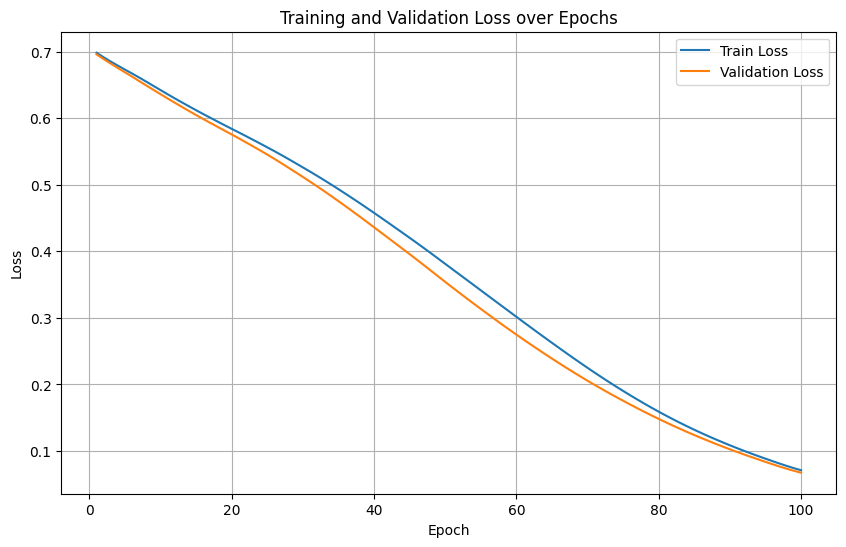

In [215]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()